In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rsnngo/37ft-thang3737/val_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/train_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/full_dataset_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/scaler_minmax_p3.2.pkl
/kaggle/input/datasets/rsnngo/37ft-thang3737/class_weights_p3.2.json
/kaggle/input/datasets/rsnngo/37ft-thang3737/test_minmax_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/feature_columns_p3.2.json
/kaggle/input/datasets/rsnngo/37ft-thang3737/val_standard_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/test_standard_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/audit_report_p3.2.json
/kaggle/input/datasets/rsnngo/37ft-thang3737/val_minmax_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/scaler_standard_p3.2.pkl
/kaggle/input/datasets/rsnngo/37ft-thang3737/test_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/dist_label8_precap_vs_postcap_p3.2.png
/kaggle/input/datasets/rsnng

In [2]:
# ╔══════════════════════════════════════════════════════════╗
# ║              CELL 1 — CẤU HÌNH & IMPORT                 ║
# ╚══════════════════════════════════════════════════════════╝
!pip install -q optuna

import os, json, time, gc, pickle, glob
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, backend as K
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 120
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, roc_auc_score,
    f1_score, accuracy_score, precision_recall_fscore_support
)
from sklearn.preprocessing import label_binarize
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Đường dẫn ──────────────────────────────────────────────
TRAIN_PATH = "/kaggle/input/datasets/rsnngo/37ft-thang3737/train_standard_p3.2.parquet"
VAL_PATH   = "/kaggle/input/datasets/rsnngo/37ft-thang3737/val_standard_p3.2.parquet"
TEST_PATH  = "/kaggle/input/datasets/rsnngo/37ft-thang3737/test_standard_p3.2.parquet"
OUTPUT_DIR = "/kaggle/working/"
TARGET_COL = "label"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Checkpoint Optuna ─────────────────────────────────────
OPTUNA_STUDY_PATH = os.path.join(OUTPUT_DIR, 'optuna_study_mlp_37ft.pkl')

LABEL_NAMES = {
    0: 'Benign', 1: 'DDoS',  2: 'DoS',      3: 'BruteForce',
    4: 'Spoofing', 5: 'Recon', 6: 'Web-Based', 7: 'Mirai'
}

# ── Kiến trúc MLP ──────────────────────────────────────────
HIDDEN_UNITS = [256, 128, 64, 32]   # 4 lớp ẩn
DROPOUT_RATE = 0.3
LEAKY_ALPHA  = 0.1                  # hệ số cho LeakyReLU

# ── Optuna search space ──────────────────────────────────
OPTUNA_N_TRIALS   = 20
OPTUNA_EPOCHS     = 50
OPTUNA_LR_LOW     = 1e-5
OPTUNA_LR_HIGH    = 0.3
OPTUNA_BS_CHOICES = [64, 128, 256, 512]

# ── Train chính thức ────────────────────────────────────
FINAL_MAX_EPOCHS = 50
RANDOM_SEED      = 42

# ── Timeout ─────────────────────────────────────────────
TIMEOUT_S = 3600 * 12          # 12 giờ
T_START   = time.time()
DEADLINE  = T_START + TIMEOUT_S

# ── Seed ──────────────────────────────────────────────────
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print('=' * 58)
print('  MLP [256,128,64,32] Teacher Model + Optuna — CICIoT2023 (8 classes)')
print('=' * 58)
print(f"  TensorFlow version  : {tf.__version__}")
print(f"  GPU available       : {tf.config.list_physical_devices('GPU')}")
print()
print('  [Kiến trúc — MLP]')
print(f'  Hidden layers       : {HIDDEN_UNITS}')
print('  Activation          : LeakyReLU(alpha=0.1)')
print('  BatchNormalization  : sau mỗi Dense (trước activation)')
print(f'  Dropout {DROPOUT_RATE} : sau mỗi BatchNorm + Activation')
print('  Optimizer           : Adam | loss: sparse_categorical_crossentropy')
print()
print(f'  n_trials            : {OPTUNA_N_TRIALS}')
print(f'  epoch/trial         : {OPTUNA_EPOCHS}  (không early stop)')
print(f'  lr                  : log-uniform [{OPTUNA_LR_LOW}, {OPTUNA_LR_HIGH}]')
print(f'  batch_size          : categorical {OPTUNA_BS_CHOICES}')
print('  objective           : maximize val macro-F1')
print('  pruner              : MedianPruner(n_startup_trials=3, n_warmup_steps=5)')
print()
print(f'  Train chính thức    : {FINAL_MAX_EPOCHS} epoch (lưu best epoch theo val loss thấp nhất)')
print('=' * 58)
print(f'  TIMEOUT             : {TIMEOUT_S/3600:.1f} giờ (deadline tính từ lúc kernel start)')

  MLP [256,128,64,32] Teacher Model + Optuna — CICIoT2023 (8 classes)
  TensorFlow version  : 2.20.0
  GPU available       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

  [Kiến trúc — MLP]
  Hidden layers       : [256, 128, 64, 32]
  Activation          : LeakyReLU(alpha=0.1)
  BatchNormalization  : sau mỗi Dense (trước activation)
  Dropout 0.3 : sau mỗi BatchNorm + Activation
  Optimizer           : Adam | loss: sparse_categorical_crossentropy

  n_trials            : 20
  epoch/trial         : 50  (không early stop)
  lr                  : log-uniform [1e-05, 0.3]
  batch_size          : categorical [64, 128, 256, 512]
  objective           : maximize val macro-F1
  pruner              : MedianPruner(n_startup_trials=3, n_warmup_steps=5)

  Train chính thức    : 50 epoch (lưu best epoch theo val loss thấp nhất)
  TIMEOUT             : 12.0 giờ (deadline tính từ lúc kernel start)


In [3]:
# ╔══════════════════════════════════════════════════════════╗
# ║              CELL 2 — LOAD DATA                         ║
# ║  Load và giữ nguyên dạng 2D (samples, features) cho MLP ║
# ╚══════════════════════════════════════════════════════════╝
df_train = pd.read_parquet(TRAIN_PATH)
df_val   = pd.read_parquet(VAL_PATH)
df_test  = pd.read_parquet(TEST_PATH)

feature_cols = [c for c in df_train.columns if c != TARGET_COL]

X_train = df_train[feature_cols].values.astype(np.float32)
y_train = df_train[TARGET_COL].values.astype(np.int32)
X_val   = df_val[feature_cols].values.astype(np.float32)
y_val   = df_val[TARGET_COL].values.astype(np.int32)
X_test  = df_test[feature_cols].values.astype(np.float32)
y_test  = df_test[TARGET_COL].values.astype(np.int32)

NUM_CLASSES  = int(np.max(y_train)) + 1
NUM_FEATURES = X_train.shape[1]

# Không reshape – MLP nhận đầu vào 2D

# Lưu metadata
with open(f"{OUTPUT_DIR}metadata_mlp.json", "w") as f:
    json.dump({"feature_cols": feature_cols, "target_col": TARGET_COL,
               "num_classes": NUM_CLASSES, "num_features": NUM_FEATURES}, f, indent=4)

print(f"Train : {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Num classes: {NUM_CLASSES} | Num features: {NUM_FEATURES}")
print("\nPhân bố lớp (train):")
for c in range(NUM_CLASSES):
    n = int((y_train == c).sum())
    print(f"  {c} {LABEL_NAMES.get(c, c):<11}: {n:>9,}  ({n/len(y_train)*100:5.2f}%)")

del df_train, df_val, df_test
gc.collect()

Train : (4468344, 37) | Val: (1117087, 37) | Test: (1396358, 37)
Num classes: 8 | Num features: 37

Phân bố lớp (train):
  0 Benign     :   670,231  (15.00%)
  1 DDoS       : 1,916,729  (42.90%)
  2 DoS        :   619,802  (13.87%)
  3 BruteForce :     8,013  ( 0.18%)
  4 Spoofing   :   278,953  ( 6.24%)
  5 Recon      :   383,443  ( 8.58%)
  6 Web-Based  :    15,173  ( 0.34%)
  7 Mirai      :   576,000  (12.89%)


33

In [4]:
# ╔══════════════════════════════════════════════════════════╗
# ║   CELL 3 — KIẾN TRÚC MLP [256,128,64,32]               ║
# ║   Dense → BatchNorm → LeakyReLU → Dropout (0.3)        ║
# ║   Output: Dense(8, softmax)                            ║
# ╚══════════════════════════════════════════════════════════╝
def build_mlp_model(learning_rate, input_dim, num_classes):
    """
    Xây dựng MLP với 4 lớp ẩn:
    - Dense(256) → BatchNorm → LeakyReLU → Dropout(0.3)
    - Dense(128) → BatchNorm → LeakyReLU → Dropout(0.3)
    - Dense(64)  → BatchNorm → LeakyReLU → Dropout(0.3)
    - Dense(32)  → BatchNorm → LeakyReLU → Dropout(0.3)
    - Dense(num_classes, softmax)
    """
    inp = layers.Input(shape=(input_dim,))
    x = inp
    for units in HIDDEN_UNITS:
        x = layers.Dense(units)(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(alpha=LEAKY_ALPHA)(x)
        x = layers.Dropout(DROPOUT_RATE)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

_m = build_mlp_model(1e-3, NUM_FEATURES, NUM_CLASSES)
_m.summary()
print(f"\nTổng params: {_m.count_params():,}")
del _m
K.clear_session()
gc.collect()

I0000 00:00:1785640366.995841      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785640367.001737      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 37)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         9,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,144 (215.41 KB)

 Trainable params: 54,184 (211.66 KB)

 Non-trainable params: 960 (3.75 KB)


Tổng params: 55,144


0

In [5]:
# ╔══════════════════════════════════════════════════════════╗
# ║   CELL 4 — OPTUNA HYPERPARAMETER SEARCH                 ║
# ║   Pipeline tương tự nhưng dùng model MLP                ║
# ╚══════════════════════════════════════════════════════════╝

class _OptunaPruneCallback(tf.keras.callbacks.Callback):
    def __init__(self, trial, X_val, y_val, eval_bs=1024):
        super().__init__()
        self.trial   = trial
        self.X_val   = X_val
        self.y_val   = y_val
        self.eval_bs = eval_bs
        self.last_f1 = 0.0

    def on_epoch_end(self, epoch, logs=None):
        val_proba = self.model.predict(self.X_val, batch_size=self.eval_bs, verbose=0)
        val_preds = np.argmax(val_proba, axis=1)
        macro_f1  = f1_score(self.y_val, val_preds, average='macro', zero_division=0)
        self.last_f1 = macro_f1
        self.trial.report(macro_f1, epoch + 1)
        if self.trial.should_prune():
            raise optuna.exceptions.TrialPruned()


def optuna_objective(trial):
    lr         = trial.suggest_float('lr', OPTUNA_LR_LOW, OPTUNA_LR_HIGH, log=True)
    batch_size = trial.suggest_categorical('batch_size', OPTUNA_BS_CHOICES)

    K.clear_session()
    model = build_mlp_model(lr, NUM_FEATURES, NUM_CLASSES)

    prune_cb = _OptunaPruneCallback(trial, X_val, y_val)

    try:
        model.fit(
            X_train, y_train,
            batch_size=batch_size,
            epochs=OPTUNA_EPOCHS,
            validation_data=(X_val, y_val),
            callbacks=[prune_cb],
            verbose=0
        )
        val_macro_f1 = prune_cb.last_f1
    finally:
        del model
        K.clear_session()
        gc.collect()

    return val_macro_f1


# ── Quản lý study với checkpoint ──────────────────────────
def _n_finished(st):
    return len([t for t in st.trials if t.state.is_finished()])

def _save_ckpt(st):
    tmp = OPTUNA_STUDY_PATH + '.tmp'
    with open(tmp, 'wb') as f:
        pickle.dump(st, f)
    os.replace(tmp, OPTUNA_STUDY_PATH)

def _find_input_checkpoint():
    for p in sorted(glob.glob('/kaggle/input/datasets/lamthicucb2203709/mlp-teach-ckpt/optuna_study_mlp_37ft.pkl', recursive=True)):
        try:
            with open(p, 'rb') as f:
                obj = pickle.load(f)
            if isinstance(obj, optuna.study.Study):
                return p, obj
        except Exception:
            continue
    return None, None

# ── Nạp study ──────────────────────────────────────────────
study = None
if os.path.isfile(OPTUNA_STUDY_PATH):
    with open(OPTUNA_STUDY_PATH, 'rb') as f:
        study = pickle.load(f)
    print(f'[Optuna] Resume từ OUTPUT: {OPTUNA_STUDY_PATH}')
else:
    _p, _st = _find_input_checkpoint()
    if _st is not None:
        study = _st
        print(f'[Optuna] Resume từ INPUT: {_p}')

if study is None:
    sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
    pruner  = optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=5)
    study   = optuna.create_study(direction='maximize',
                                  sampler=sampler, pruner=pruner)
    print(f'[Optuna] Tạo study MỚI — mục tiêu {OPTUNA_N_TRIALS} trials x {OPTUNA_EPOCHS} epoch/trial')

n_done      = _n_finished(study)
n_remaining = max(0, OPTUNA_N_TRIALS - n_done)
print(f'[Optuna] Đã xong {n_done}/{OPTUNA_N_TRIALS} trials — cần chạy thêm {n_remaining}')

_save_ckpt(study)   # đảm bảo có checkpoint ngay từ đầu

def _ckpt_deadline_cb(st, trial):
    _save_ckpt(st)
    left = DEADLINE - time.time()
    print(f'[Optuna] trial #{trial.number} {trial.state.name} — '
          f'{_n_finished(st)}/{OPTUNA_N_TRIALS} | còn {left/60:.1f} phút | checkpoint đã lưu')
    if time.time() >= DEADLINE:
        print('[Optuna] ⏰ Chạm DEADLINE → dừng sau trial này.')
        st.stop()

if n_remaining > 0:
    _budget = DEADLINE - time.time()
    if _budget > 0:
        t_optuna = time.time()
        study.optimize(optuna_objective,
                       n_trials=n_remaining,
                       timeout=_budget,
                       callbacks=[_ckpt_deadline_cb],
                       gc_after_trial=True,
                       show_progress_bar=True)
        print(f'[Optuna] Phiên này chạy {(time.time()-t_optuna)/60:.1f} phút')
    else:
        print('[Optuna] ⏰ Hết ngân sách thời gian trước khi kịp chạy trial nào.')

_save_ckpt(study)
n_done          = _n_finished(study)
OPTUNA_FINISHED = n_done >= OPTUNA_N_TRIALS
PIPELINE_CONTINUE = OPTUNA_FINISHED

print()
print('=' * 58)
if OPTUNA_FINISHED:
    print(f'[Optuna] ✓ HOÀN TẤT {n_done}/{OPTUNA_N_TRIALS} trials')
    print(f'  Checkpoint: {OPTUNA_STUDY_PATH}')
else:
    print(f'[Optuna] ⏸ DỪNG DO TIMEOUT — mới xong {n_done}/{OPTUNA_N_TRIALS} trials')
    print(f'  Checkpoint đã lưu: {OPTUNA_STUDY_PATH}')
    print('  → Các bước tiếp theo:')
    print(f'    1. Tải {os.path.basename(OPTUNA_STUDY_PATH)} từ Output của run này')
    print('    2. Upload làm dataset input (chỉ chứa 1 file .pkl này)')
    print('    3. Add dataset đó vào notebook rồi Run lại — study tự resume')
    print('  Các cell phía sau (viz / train / eval) sẽ TỰ ĐỘNG BỎ QUA ở run này.')
print('=' * 58)

if OPTUNA_FINISHED:
    best_params              = study.best_params
    best_val_macro_f1_optuna = study.best_value
    BEST_LR         = best_params['lr']
    BEST_BATCH_SIZE = best_params['batch_size']

    with open(f"{OUTPUT_DIR}best_params_mlp.json", "w") as f:
        json.dump(best_params, f, indent=4)

    print()
    print('=' * 58)
    print('  KẾT QUẢ OPTUNA SEARCH')
    print('=' * 58)
    print(f'  Best val macro-F1 : {best_val_macro_f1_optuna:.6f}')
    print(f'  lr                = {BEST_LR:.7f}')
    print(f'  batch_size        = {BEST_BATCH_SIZE}')
    print('=' * 58)
    print('\nTrain chính thức sẽ dùng các tham số này.')

[Optuna] Resume từ INPUT: /kaggle/input/datasets/lamthicucb2203709/mlp-teach-ckpt/optuna_study_mlp_37ft.pkl
[Optuna] Đã xong 16/20 trials — cần chạy thêm 4


  0%|          | 0/4 [00:00<?, ?it/s]

I0000 00:00:1785640379.113362      82 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


[Optuna] trial #16 COMPLETE — 17/20 | còn 693.3 phút | checkpoint đã lưu


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


[Optuna] trial #17 COMPLETE — 18/20 | còn 666.9 phút | checkpoint đã lưu


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


[Optuna] trial #18 PRUNED — 19/20 | còn 649.4 phút | checkpoint đã lưu


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


[Optuna] trial #19 PRUNED — 20/20 | còn 640.1 phút | checkpoint đã lưu
[Optuna] Phiên này chạy 79.7 phút

[Optuna] ✓ HOÀN TẤT 20/20 trials
  Checkpoint: /kaggle/working/optuna_study_mlp_37ft.pkl

  KẾT QUẢ OPTUNA SEARCH
  Best val macro-F1 : 0.659224
  lr                = 0.0019075
  batch_size        = 512

Train chính thức sẽ dùng các tham số này.


In [6]:
# ── GUARD ─────────────────────────────────────────────────
if not globals().get('PIPELINE_CONTINUE', True):
    print('⏭ BỎ QUA cell này — Optuna chưa đủ trials.')
else:
    # ── CELL 6 — TRAIN CHÍNH THỨC VỚI BEST PARAMS ────────
    with open(f"{OUTPUT_DIR}best_params_mlp.json", "r") as f:
        best_params = json.load(f)
    BEST_LR         = best_params['lr']
    BEST_BATCH_SIZE = best_params['batch_size']

    MODEL_PATH = f"{OUTPUT_DIR}best_model_mlp_50epoch.keras"

    print('=' * 58)
    print('  TRAIN CHÍNH THỨC — MLP [256,128,64,32]')
    print(f'  Batch={BEST_BATCH_SIZE}, LR={BEST_LR:.6f}')
    print(f'  MaxEpoch={FINAL_MAX_EPOCHS}  (KHÔNG EarlyStopping)')
    print('  Lưu best epoch theo val loss thấp nhất')
    print('=' * 58)

    K.clear_session()
    tf.random.set_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    model = build_mlp_model(BEST_LR, NUM_FEATURES, NUM_CLASSES)
    print('  Model khởi tạo random (train từ đầu).')

    checkpoint = callbacks.ModelCheckpoint(
        MODEL_PATH,
        monitor='val_loss',
        mode='min',
        save_best_only=True,
        verbose=1
    )

    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        batch_size=BEST_BATCH_SIZE,
        epochs=FINAL_MAX_EPOCHS,
        validation_data=(X_val, y_val),
        callbacks=[checkpoint],
        verbose=1
    )
    train_time = time.time() - start_time

    hist          = history.history
    best_epoch    = int(np.argmin(hist['val_loss'])) + 1
    best_val_loss = float(np.min(hist['val_loss']))

    model = tf.keras.models.load_model(MODEL_PATH)

    with open(f"{OUTPUT_DIR}train_time_mlp.txt", "w") as f:
        f.write(str(train_time))

    print(f'\n==> Training done. {train_time:.1f}s ({train_time/60:.1f} phút)')
    print(f'    Best epoch : {best_epoch}/{FINAL_MAX_EPOCHS}  |  Best val loss : {best_val_loss:.6f}')
    print(f'    Model tốt nhất được lưu tại: {MODEL_PATH}')

  TRAIN CHÍNH THỨC — MLP [256,128,64,32]
  Batch=512, LR=0.001908
  MaxEpoch=50  (KHÔNG EarlyStopping)
  Lưu best epoch theo val loss thấp nhất
  Model khởi tạo random (train từ đầu).


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
8728/8728 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7743 - loss: 0.5284
Epoch 1: val_loss improved from None to 0.39891, saving model to /kaggle/working/best_model_mlp_50epoch.keras

Epoch 1: finished saving model to /kaggle/working/best_model_mlp_50epoch.keras
8728/8728 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - accuracy: 0.7972 - loss: 0.4615 - val_accuracy: 0.8183 - val_loss: 0.3989
Epoch 2/50
8723/8728 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8106 - loss: 0.4253
Epoch 2: val_loss improved from 0.39891 to 0.38790, saving model to /kaggle/working/best_model_mlp_50epoch.keras

Epoch 2: finished saving model to /kaggle/working/best_model_mlp_50epoch.keras
8728/8728 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.8121 - loss: 0.4224 - val_accuracy: 0.8252 - val_loss: 0.3879
Epoch 3/50
8717/8728 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8152 - loss: 0.4161
Epoch 3: val_loss improved from 0.38790 to 0.37001, saving model to /kaggle/working/best_model_mlp_50epoch.keras


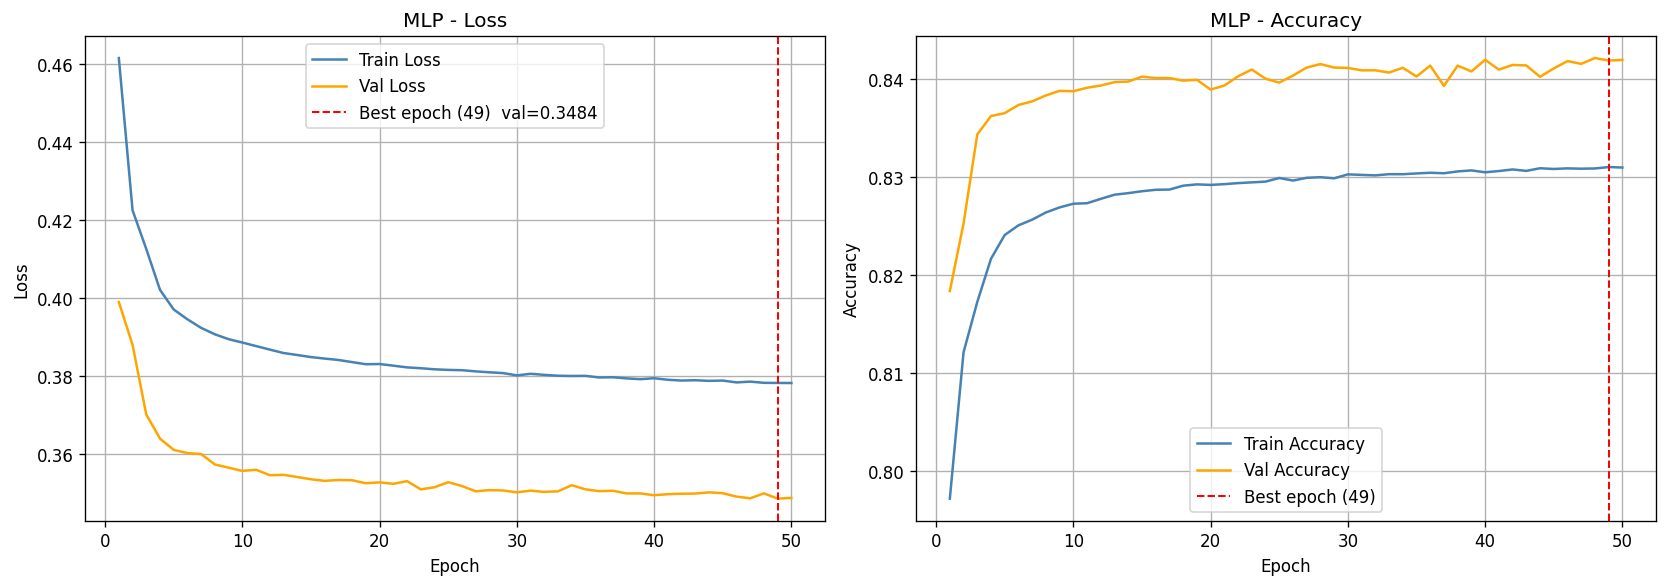

✅ Đã lưu biểu đồ training curves.


In [7]:
# ── GUARD ─────────────────────────────────────────────────
if not globals().get('PIPELINE_CONTINUE', True):
    print('⏭ BỎ QUA cell này — Optuna chưa đủ trials.')
else:
    # ── CELL 7 — Biểu đồ training curves ──────────────────
    hist = history.history
    epochs_range = range(1, len(hist['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs_range, hist['loss'], label='Train Loss', color='steelblue')
    axes[0].plot(epochs_range, hist['val_loss'], label='Val Loss', color='orange')
    axes[0].axvline(best_epoch, color='red', linestyle='--', linewidth=1.2,
                    label=f'Best epoch ({best_epoch})  val={best_val_loss:.4f}')
    axes[0].set_title('MLP - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs_range, hist['accuracy'], label='Train Accuracy', color='steelblue')
    axes[1].plot(epochs_range, hist['val_accuracy'], label='Val Accuracy', color='orange')
    axes[1].axvline(best_epoch, color='red', linestyle='--', linewidth=1.2,
                    label=f'Best epoch ({best_epoch})')
    axes[1].set_title('MLP - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}training_curves.png", dpi=150)
    plt.show()
    print("✅ Đã lưu biểu đồ training curves.")

10910/10910 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step
===== Classification Report =====
              precision    recall  f1-score   support

           0     0.7696    0.8920    0.8263    209448
           1     0.8550    0.9387    0.8949    598978
           2     0.7332    0.5057    0.5986    193688
           3     0.9201    0.1977    0.3254      2504
           4     0.8986    0.7660    0.8270     87173
           5     0.7588    0.6872    0.7212    119826
           6     0.9890    0.0190    0.0373      4741
           7     0.9993    0.9935    0.9964    180000

    accuracy                         0.8419   1396358
   macro avg     0.8654    0.6250    0.6534   1396358
weighted avg     0.8389    0.8419    0.8335   1396358


Accuracy      : 0.8419
Macro F1      : 0.6534
Weighted F1   : 0.8335


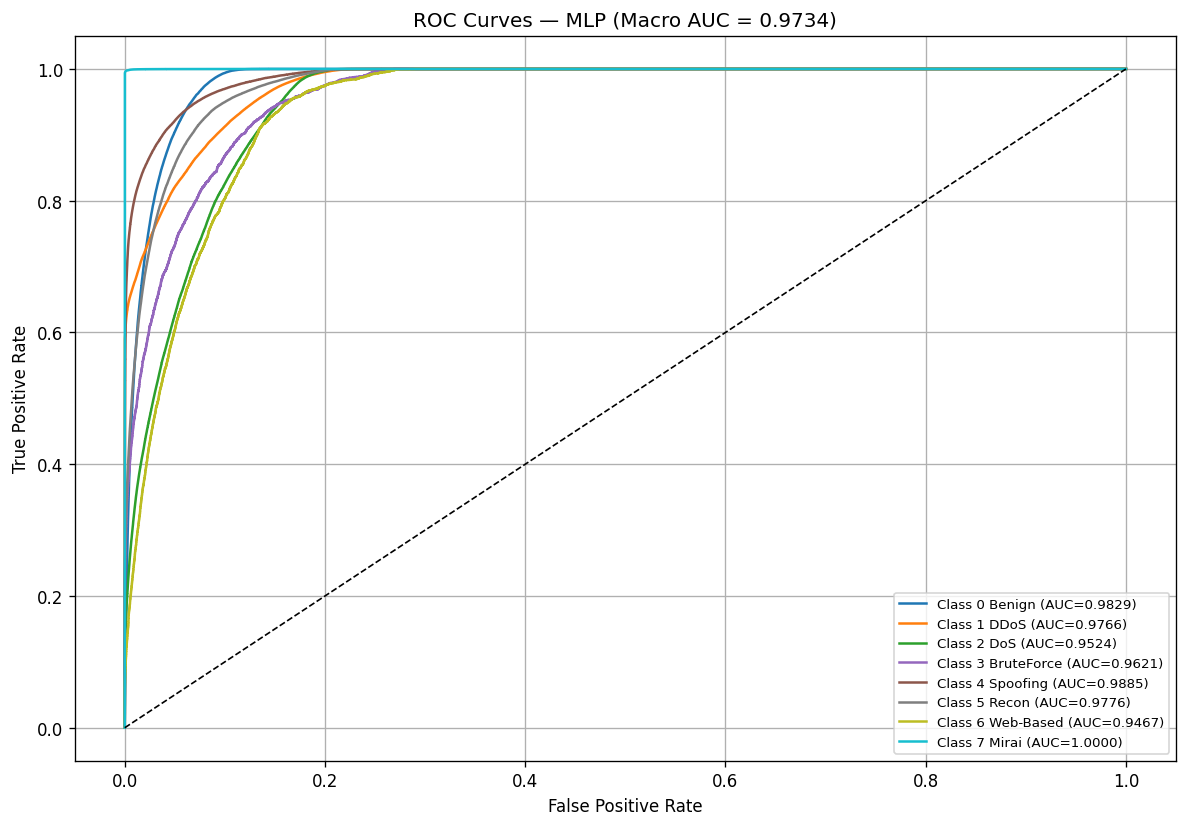

Macro AUC: 0.9734


In [8]:
# ── GUARD ─────────────────────────────────────────────────
if not globals().get('PIPELINE_CONTINUE', True):
    print('⏭ BỎ QUA cell này — Optuna chưa đủ trials.')
else:
    # ── CELL 8 — Đánh giá trên tập test ─────────────────────
    best_model = tf.keras.models.load_model(MODEL_PATH)

    y_proba = best_model.predict(X_test, batch_size=128, verbose=1)
    y_pred = np.argmax(y_proba, axis=1)

    report = classification_report(y_test, y_pred, digits=4, zero_division=0)
    print("===== Classification Report =====")
    print(report)
    with open(f"{OUTPUT_DIR}classification_report.txt", "w") as f:
        f.write(report)

    acc = accuracy_score(y_test, y_pred)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0)
    prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted', zero_division=0)

    print(f"\nAccuracy      : {acc:.4f}")
    print(f"Macro F1      : {f1_macro:.4f}")
    print(f"Weighted F1   : {f1_weighted:.4f}")

    metrics = {
        'accuracy': acc,
        'macro_f1': f1_macro,
        'weighted_f1': f1_weighted,
        'macro_precision': prec_macro,
        'macro_recall': rec_macro,
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss,
        'best_lr': BEST_LR,
        'best_batch_size': BEST_BATCH_SIZE,
        'optuna_best_val_macro_f1': float(best_val_macro_f1_optuna),
    }
    with open(f"{OUTPUT_DIR}test_metrics.json", "w") as f:
        json.dump(metrics, f, indent=4)

    # ── ROC Curves & AUC ────────────────────────────────────
    y_test_bin = label_binarize(y_test, classes=range(NUM_CLASSES))
    plt.figure(figsize=(10, 7))
    colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
    auc_scores = []
    for i, color in enumerate(colors):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        auc_val = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
        auc_scores.append(auc_val)
        plt.plot(fpr, tpr, color=color, lw=1.5,
                 label=f'Class {i} {LABEL_NAMES.get(i, "")} (AUC={auc_val:.4f})')
    macro_auc = np.mean(auc_scores)
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves — MLP (Macro AUC = {macro_auc:.4f})')
    plt.legend(loc='lower right', fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}roc_curves.png", dpi=150)
    plt.show()
    print(f"Macro AUC: {macro_auc:.4f}")
    with open(f"{OUTPUT_DIR}macro_auc.txt", "w") as f:
        f.write(str(macro_auc))

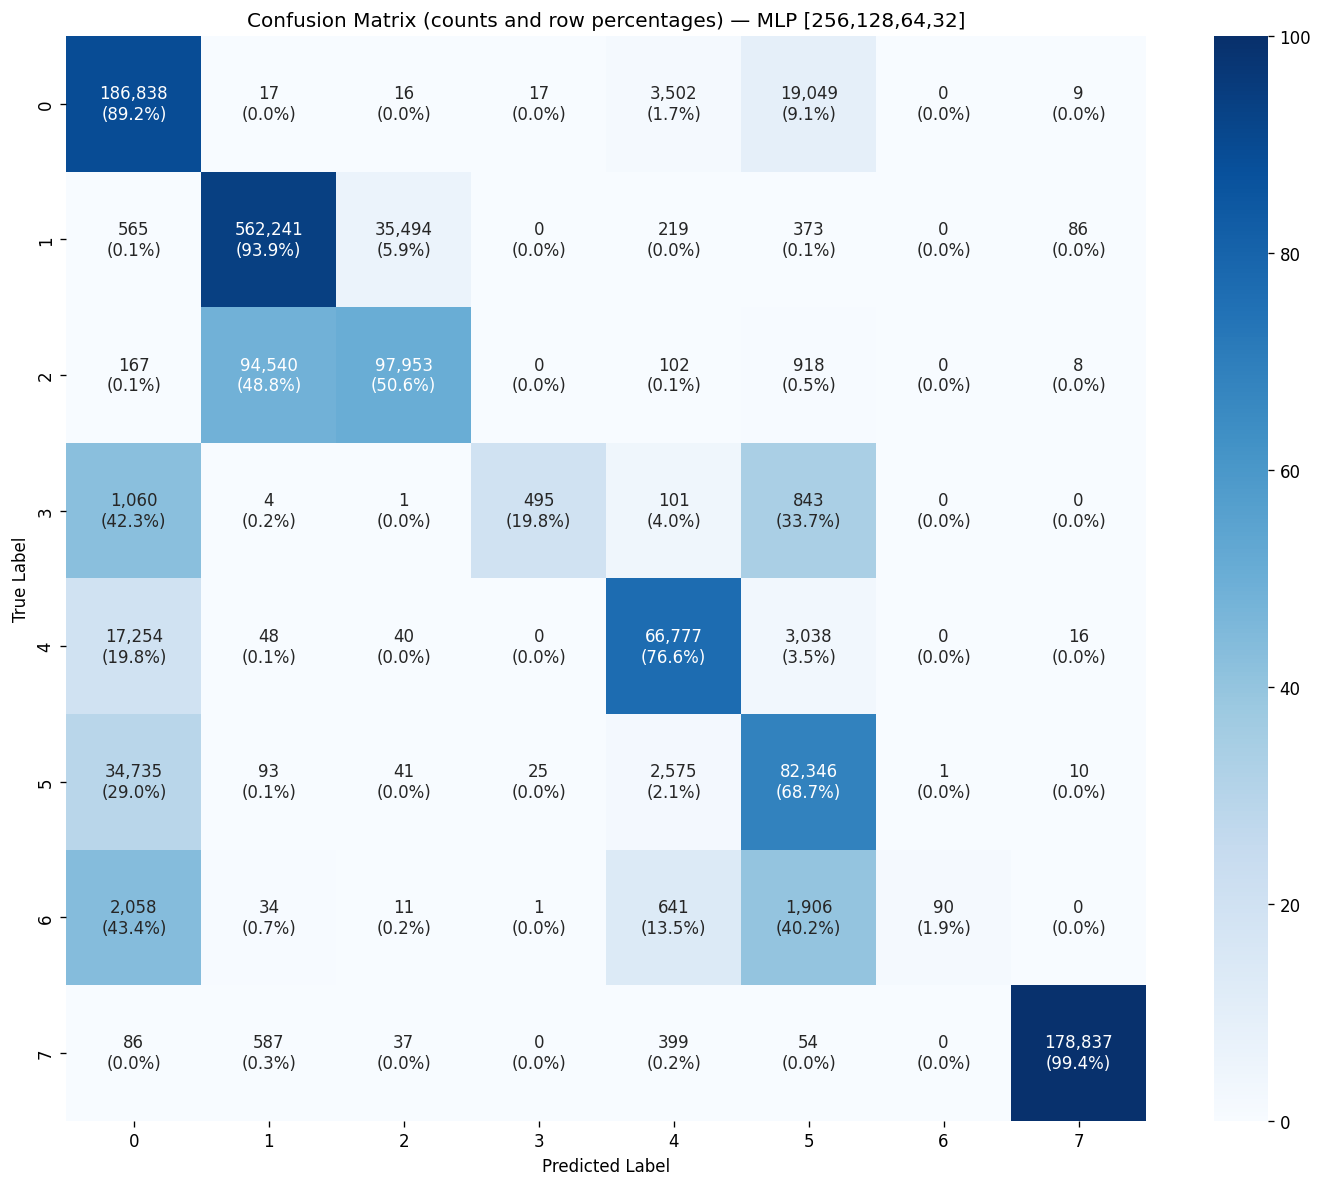

✅ Đã lưu confusion matrix.


In [9]:
# ── GUARD ─────────────────────────────────────────────────
if not globals().get('PIPELINE_CONTINUE', True):
    print('⏭ BỎ QUA cell này — Optuna chưa đủ trials.')
else:
    # ── CELL 9 — Confusion Matrix ──────────────────────────
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    annot = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)"

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_pct, annot=annot, fmt='', cmap='Blues',
                xticklabels=range(NUM_CLASSES),
                yticklabels=range(NUM_CLASSES),
                vmin=0, vmax=100)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (counts and row percentages) — MLP [256,128,64,32]')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}confusion_matrix.png", dpi=150)
    plt.show()
    print("✅ Đã lưu confusion matrix.")

In [10]:
# ── GUARD ─────────────────────────────────────────────────
if not globals().get('PIPELINE_CONTINUE', True):
    print('⏭ BỎ QUA cell này — Optuna chưa đủ trials.')
else:
    # ── CELL 10 — Heaviness Metrics ────────────────────────
    model_path = MODEL_PATH
    size_bytes = os.path.getsize(model_path)
    size_mb = size_bytes / (1024 * 1024)

    total_params = best_model.count_params()
    trainable_params = sum(tf.keras.backend.count_params(w) for w in best_model.trainable_weights)

    for _ in range(5):
        best_model.predict(X_test[:100], batch_size=128, verbose=0)
    N = 2000
    t0 = time.perf_counter()
    best_model.predict(X_test[:N], batch_size=128, verbose=0)
    inf_time_per_sample = (time.perf_counter() - t0) * 1000 / N

    heaviness = {
        "model_size_mb": round(size_mb, 6),
        "total_params": int(total_params),
        "trainable_params": int(trainable_params),
        "train_time_s": round(train_time, 4),
        "inference_ms_per_sample": round(inf_time_per_sample, 6)
    }
    print("===== Heaviness Metrics =====")
    for k, v in heaviness.items():
        print(f"  {k:<25s}: {v}")
    with open(f"{OUTPUT_DIR}heaviness.json", "w") as f:
        json.dump(heaviness, f, indent=4)

    # ── Tổng kết file đã xuất ────────────────────────────────
    print()
    print('=' * 58)
    print('  FILE ĐÃ XUẤT TRONG', OUTPUT_DIR)
    print('=' * 58)
    for fn in sorted(os.listdir(OUTPUT_DIR)):
        fp = os.path.join(OUTPUT_DIR, fn)
        if os.path.isfile(fp):
            print(f"  {fn:<40} {os.path.getsize(fp)/1024:>10.1f} KB")
    print('=' * 58)

===== Heaviness Metrics =====
  model_size_mb            : 0.701882
  total_params             : 55144
  trainable_params         : 54184
  train_time_s             : 1493.8825
  inference_ms_per_sample  : 0.21769

  FILE ĐÃ XUẤT TRONG /kaggle/working/
  __notebook__.ipynb                          11276.3 KB
  best_model_mlp_50epoch.keras                  718.7 KB
  best_params_mlp.json                            0.1 KB
  classification_report.txt                       0.6 KB
  confusion_matrix.png                          178.2 KB
  heaviness.json                                  0.2 KB
  macro_auc.txt                                   0.0 KB
  metadata_mlp.json                               0.8 KB
  optuna_study_mlp_37ft.pkl                      23.0 KB
  roc_curves.png                                146.4 KB
  test_metrics.json                               0.4 KB
  train_time_mlp.txt                              0.0 KB
  training_curves.png                           102.0 KB
